# Sentence Embeddings — Notebook 2 (Clase 4, Parte 2)

*De la palabra a la oración, y de ahí a la búsqueda semántica: el motor de recuperación de RAG.*

Este notebook es la **Parte 2** de la Clase 4 y acompaña al deck de sentence embeddings. En la **Parte 1** (Notebook 1) vimos de dónde salen los vectores de *palabra* —one-hot → contar → word2vec → GloVe— y cerramos con una bisagra: `most_similar` (buscar los vectores más cercanos por coseno) es, literalmente, la recuperación de RAG (láminas 37–39 del deck de P1).

Ahora damos el paso que faltaba: el vector de una **oración entera**. Con eso montamos **búsqueda semántica** y, al final, un **RAG mínimo** con el mismo stack local que usamos en todo el curso.

**El recorrido, de a un paso:**
1. De la palabra a la oración: el problema.
2. Baseline: promediar word vectors — y dónde se rompe.
3. SBERT: un modelo que embebe la oración entera.
4. Coseno entre oraciones.
5. Búsqueda semántica = la «R» de RAG.
6. Del retrieval a RAG: el stack Ollama-nativo (anticipo de la Unidad 4).

> **Activá la GPU:** *Entorno de ejecución → Cambiar tipo de entorno de ejecución → T4 GPU.* No es obligatoria para las §1–§5 (los modelos son chicos y andan en CPU), pero acelera la §6 (Ollama + qwen3).

## 0 · Preparación

Instalamos lo que vamos a usar y dejamos listo el andamiaje reutilizable: la **misma función de coseno** de N1, la semilla fija (`1337`) y los word vectors de GloVe (los mismos de la Parte 1). El bootstrap de Ollama para la §6 lo dejamos para esa sección, así las §1–§5 arrancan livianas.

In [ ]:
# Instalamos las dos librerías nuevas de esta clase.
# - sentence-transformers (SBERT): el modelo que embebe oraciones enteras (§3-§5).
# - gensim: para cargar los word vectors de GloVe pre-entrenados (los mismos de N1, §2).
!pip -q install -U sentence-transformers
!pip -q install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 739.6/739.6 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.8/27.8 MB 49.0 MB/s eta 0:00:00


In [ ]:
import numpy as np

# Semilla fija: mismos resultados en cada corrida (convención del curso).
np.random.seed(1337)

# La MISMA función de coseno de N1. La reusamos en TODO el notebook.
# cos(a,b) = (a · b) / (||a|| ||b||)  ->  mide DIRECCIÓN, no tamaño (lámina 5 del deck de P1).
def coseno(a, b):
    a = np.asarray(a, dtype=np.float32)
    b = np.asarray(b, dtype=np.float32)
    return float(a @ b / (np.linalg.norm(a) * np.linalg.norm(b) + 1e-9))

# Sanity check: un vector consigo mismo da 1.0; con su opuesto, -1.0.
v = np.array([1.0, 2.0, 3.0])
print("cos(v, v)       =", round(coseno(v, v), 4))    # 1.0
print("cos(v, -v)      =", round(coseno(v, -v), 4))   # -1.0
print("cos(v, [3,2,1]) =", round(coseno(v, [3, 2, 1]), 4))

cos(v, v)       = 1.0
cos(v, -v)      = -1.0
cos(v, [3,2,1]) = 0.7143


**Los word vectors de la Parte 1.** Para el baseline de la §2 necesitamos vectores de *palabra*. Usamos los mismos que en N1: **GloVe pre-entrenado** (100 dimensiones), bajado con `gensim.downloader`. Son vectores en **inglés** —GloVe se entrenó sobre Wikipedia + Gigaword en inglés—, así que el baseline lo mostramos en inglés. El punto de la §2 es el *mecanismo* (promediar), no el idioma; a partir de la §4 pasamos a un corpus en español con un modelo multilingüe.

> **Si `import gensim` falla** con un error sobre `scipy.linalg.triu` o `smart_open`: reiniciá el entorno (*Entorno de ejecución → Reiniciar sesión*) y volvé a correr desde la §0. Es un desajuste de versiones conocido de Colab.

In [ ]:
import gensim.downloader as api

# GloVe 100d pre-entrenado (~130 MB, una vez por sesión). Los mismos vectores de N1 (§5).
glove = api.load("glove-wiki-gigaword-100")

print("Vocabulario:", len(glove.key_to_index), "palabras")
print("Dimensión de cada vector:", glove.vector_size)
print("Vector de 'king' (primeros 8 de 100):", np.round(glove["king"][:8], 3))

[==================================================] 100.0% 128.1/128.1MB downloaded
Vocabulario: 400000 palabras
Dimensión de cada vector: 100
Vector de 'king' (primeros 8 de 100): [-0.323 -0.876  0.22   0.253  0.23   0.739 -0.38  -0.353]


## 1 · De la palabra a la oración

**Dónde quedamos.** En la Parte 1 conseguimos un vector por **palabra**: `glove["king"]` es un vector de 100 números que captura el significado de *king*. Podemos comparar palabras con coseno, buscar la más parecida, hacer analogías.

**Lo que falta.** Casi nada de lo que nos importa es una palabra suelta. Una búsqueda es una *frase* ("cómo conectarme a la VPN"), un documento es un *párrafo*, la pregunta de un alumno es una *oración*. Para RAG necesitamos comparar **textos**, no palabras. O sea: un vector por **oración**.

**La pregunta de esta clase.** Tenemos un vector por palabra. ¿Cómo armamos un vector por oración —uno solo, de largo fijo— que capture el significado de todo el texto?

In [ ]:
# Embeber una PALABRA: listo, es un lookup en GloVe.
print("Vector de 'king':", glove["king"].shape, "->", np.round(glove["king"][:5], 3), "...")

# Embeber una ORACIÓN: todavía no sabemos. GloVe no tiene una entrada para la frase entera.
oracion = "the king rules the country"
try:
    print(glove[oracion])
except KeyError as e:
    print("\nGloVe NO tiene un vector para la oración entera:", e)
    print("Tenemos 5 vectores de palabra, y necesitamos 1 vector de oración. ¿Cómo lo armamos?")

Vector de 'king': (100,) -> [-0.323 -0.876  0.22   0.253  0.23 ] ...

GloVe NO tiene un vector para la oración entera: "Key 'the king rules the country' not present"
Tenemos 5 vectores de palabra, y necesitamos 1 vector de oración. ¿Cómo lo armamos?


## 2 · Baseline: promediar los word vectors

**La idea más simple que puede funcionar.** Si tenemos un vector por palabra, el vector de la oración puede ser el **promedio** de los vectores de sus palabras. Sumamos los 100-dim de cada palabra y dividimos por la cantidad. El resultado es un único vector de 100-dim: el "centro de masa" semántico de la oración.

**Construyámoslo.** (Este es el modo *construir desde cero*: lo armamos a mano antes de mirar la herramienta real.)

In [ ]:
def embeber_promedio(texto):
    # 1. Partimos la oración en palabras (tokenización naive: minúsculas + split por espacios).
    palabras = texto.lower().split()
    # 2. Nos quedamos con las palabras que GloVe conoce (las demás no tienen vector).
    vectores = [glove[p] for p in palabras if p in glove.key_to_index]
    # 3. Promediamos. Si ninguna palabra está en GloVe, devolvemos ceros.
    if not vectores:
        return np.zeros(glove.vector_size, dtype=np.float32)
    return np.mean(vectores, axis=0)

# Tres oraciones: dos sobre lo mismo (realeza) y una distinta (comida).
s1 = "the king rules the country"
s2 = "the monarch governs the nation"     # mismo tema, otras palabras
s3 = "i had pizza for dinner"             # tema distinto

e1, e2, e3 = embeber_promedio(s1), embeber_promedio(s2), embeber_promedio(s3)
print("Cada oración ->", e1.shape, "(un solo vector de 100-dim)\n")
print(f"cos(s1, s2) = {coseno(e1, e2):.3f}   <- {s1!r} vs {s2!r} (mismo tema)")
print(f"cos(s1, s3) = {coseno(e1, e3):.3f}   <- {s1!r} vs {s3!r} (tema distinto)")

Cada oración -> (100,) (un solo vector de 100-dim)

cos(s1, s2) = 0.929   <- 'the king rules the country' vs 'the monarch governs the nation' (mismo tema)
cos(s1, s3) = 0.759   <- 'the king rules the country' vs 'i had pizza for dinner' (tema distinto)


**Funciona sorprendentemente bien como piso.** Sin entrenar nada nuevo, promediar ya separa lo parecido de lo distinto: *king/monarch* quedan cerca, *pizza* lejos. Por años este fue un baseline difícil de superar. Pero tiene dos agujeros que lo hunden en cuanto el texto se pone serio.

In [ ]:
# AGUJERO 1: el promedio IGNORA EL ORDEN. Sumar es conmutativo: a+b = b+a.
# Dos oraciones con las MISMAS palabras en distinto orden dan el MISMO vector.
a = "the dog bit the man"
b = "the man bit the dog"     # mismas palabras, significado OPUESTO

ea, eb = embeber_promedio(a), embeber_promedio(b)
print(f"{a!r}")
print(f"{b!r}\n")
print(f"modelo -> cos = {coseno(ea, eb):.4f}   (idénticos: el promedio no ve el orden)")
print("real   -> significan lo OPUESTO (quién muerde a quién)")

'the dog bit the man'
'the man bit the dog'

modelo -> cos = 1.0000   (idénticos: el promedio no ve el orden)
real   -> significan lo OPUESTO (quién muerde a quién)


In [ ]:
# AGUJERO 2: se DILUYE con el largo, y no sabe qué palabras importan.
# Una oración larga promedia muchas palabras de relleno ("the", "of", "a") y el
# significado central se lava. Además, toda palabra fuera de GloVe se ignora en silencio.
corta = "quantum computing"
larga = "the topic of the article that we are going to read today is about quantum computing"

print(f"cos(corta, larga) = {coseno(embeber_promedio(corta), embeber_promedio(larga)):.3f}")
print("  (deberían ser casi lo mismo, pero el relleno de la larga baja la similitud)\n")

# OOV (out-of-vocabulary): palabras que GloVe no conoce desaparecen sin aviso.
rara = "the pytorch tensor broadcasts"
palabras = rara.lower().split()
conocidas = [p for p in palabras if p in glove.key_to_index]
oov = [p for p in palabras if p not in glove.key_to_index]
print(f"{rara!r}")
print("  palabras que GloVe conoce:", conocidas)
print("  ignoradas (OOV):", oov)

cos(corta, larga) = 0.433
  (deberían ser casi lo mismo, pero el relleno de la larga baja la similitud)

'the pytorch tensor broadcasts'
  palabras que GloVe conoce: ['the', 'tensor', 'broadcasts']
  ignoradas (OOV): ['pytorch']


> **El diagnóstico.** Promediar pierde el **orden** (dog/man), se **diluye** con el relleno y **descarta** lo que no está en el vocabulario. La raíz es que juntamos vectores pensados para *palabras aisladas*: nunca hubo un modelo que mirara la oración **entera** y decidiera qué es importante.

Eso es exactamente lo que vamos a traer ahora.

## 3 · SBERT: un modelo que embebe la oración entera

**El salto.** En vez de juntar vectores de palabra, usamos un modelo entrenado para producir, de una, el vector de la **oración completa**. La familia estándar para esto es **SBERT** (Sentence-BERT), en la librería `sentence-transformers`.

**De dónde sale.** Por dentro, SBERT es un Transformer —de los que ya construyeron— que lee la oración con self-attention (así que **sí ve el orden** y decide qué palabras pesan) y produce un vector. La pregunta obvia: ¿no alcanzaba con meter la oración a un BERT cualquiera y sacar un vector? No: un BERT crudo da vectores flojos para comparar por coseno. **La contribución de SBERT** fue *afinarlo* con pares de oraciones (arquitectura siamesa / triplet loss) para que **el coseno entre embeddings signifique parecido semántico**. Sin ese fine-tuning, el coseno no es confiable; con él, sí.

*El detalle interno del entrenamiento siamés lo vemos en la unidad de fine-tuning; acá lo usamos como herramienta.*

In [ ]:
from sentence_transformers import SentenceTransformer

# all-MiniLM-L6-v2: el modelo de referencia para arrancar. Chico (384-dim), rápido en CPU,
# licencia Apache-2.0. Es el default de la doc de sentence-transformers. Baja ~90 MB.
sbert = SentenceTransformer("all-MiniLM-L6-v2")

# model.encode() hace TODO: tokeniza, pasa por el Transformer, y devuelve un vector por texto.
sentences = ["the king rules the country", "the monarch governs the nation", "i had pizza for dinner"]
emb = sbert.encode(sentences)

print("Entrada:", len(sentences), "oraciones")
print("Salida :", emb.shape, "-> un vector de 384-dim por oración")
print("Primeros 5 números de la oración 1:", np.round(emb[0][:5], 3))

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Entrada: 3 oraciones
Salida : (3, 384) -> un vector de 384-dim por oración
Primeros 5 números de la oración 1: [-0.021  0.054 -0.058  0.029  0.026]


**La prueba de fuego: el orden.** Volvamos al caso que hundió al promedio —*the dog bit the man* vs *the man bit the dog*— y midámoslo ahora con SBERT.

In [ ]:
a = "the dog bit the man"
b = "the man bit the dog"

# Promedio (§2): idénticos, no ve el orden.
cos_prom = coseno(embeber_promedio(a), embeber_promedio(b))

# SBERT: lee la oración con self-attention, así que distingue quién muerde a quién.
ea, eb = sbert.encode([a, b])
cos_sbert = coseno(ea, eb)

print(f"{a!r}  vs  {b!r}\n")
print(f"promedio de GloVe -> cos = {cos_prom:.4f}   (idénticos: ciego al orden)")
print(f"SBERT             -> cos = {cos_sbert:.4f}   (< 1: registra el cambio de orden)")

'the dog bit the man'  vs  'the man bit the dog'

promedio de GloVe -> cos = 1.0000   (idénticos: ciego al orden)
SBERT             -> cos = 0.9795   (< 1: registra el cambio de orden)


> **Ojo con un detalle.** El coseno de SBERT no baja a cero: las dos oraciones comparten todas las palabras y el tema (alguien muerde a alguien), así que *son* parecidas. Pero ya no son **idénticas** como en el promedio: SBERT registra que el orden —y con él, el significado— cambió. Esa diferencia es justo lo que el promedio no podía ver.

**Un cambio necesario antes de seguir.** `all-MiniLM-L6-v2` está entrenado sobre todo en **inglés**. Nuestro corpus de acá en adelante va a estar en **español** (conceptos del curso), así que cambiamos a un modelo **multilingüe** de la misma familia. Es una decisión de práctica real: *el idioma del modelo tiene que matchear el de tus datos* —el mismo tipo de decisión que se paga caro cuando uno agarra un embedder atado a un proveedor.

In [ ]:
# Hermano multilingüe de MiniLM: 50+ idiomas (español incluido), 384-dim, también chico y Apache-2.0.
sbert_ml = SentenceTransformer("paraphrase-multilingual-MiniLM-L12-v2")

# Sanity check en español: dos oraciones parecidas vs una distinta.
pares = sbert_ml.encode([
    "el gato duerme en el sofá",
    "el felino descansa en el sillón",   # mismo sentido, otras palabras
    "la bolsa cerró en alza hoy",        # tema distinto
])
print("Salida:", pares.shape)
print(f"cos(gato, felino) = {coseno(pares[0], pares[1]):.3f}   (parecidas)")
print(f"cos(gato, bolsa)  = {coseno(pares[0], pares[2]):.3f}   (distintas)")

modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/3.89k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/645 [00:00<?, ?B/s]

...

tokenizer.json: reconstructing file:   0%|          |  0.00B / 9.08MB            

tokenizer.json: downloading bytes:           |  0.00B            

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Salida: (3, 384)
cos(gato, felino) = 0.680   (parecidas)
cos(gato, bolsa)  = 0.061   (distintas)


## 4 · Coseno entre oraciones: nuestro corpus

Ahora armamos el **corpus** con el que vamos a trabajar el resto del notebook: una pequeña **base de conocimiento** de definiciones de conceptos del curso. Es a propósito parecido a lo que un sistema de RAG guarda: pedacitos de texto que después vamos a recuperar por significado.

In [ ]:
# Base de conocimiento: una definición corta por concepto del curso.
documentos = [
    "La tokenización parte el texto en unidades llamadas tokens; el algoritmo más usado es BPE, que fusiona los pares de bytes más frecuentes.",
    "Un embedding es un vector denso que representa un token o una oración, y ubica los significados parecidos cerca en el espacio.",
    "La self-attention deja que cada token mire a los demás y arme una representación contextual, ponderando por relevancia con query, key y value.",
    "El Transformer es la arquitectura basada enteramente en atención, sin recurrencia, que hoy es la base de casi todos los modelos de lenguaje.",
    "Softmax convierte un vector de logits en una distribución de probabilidad: cada salida queda entre 0 y 1 y todas suman 1.",
    "word2vec aprende embeddings de palabra prediciendo el contexto de cada una; su variante skip-gram predice las palabras vecinas.",
    "El fine-tuning ajusta un modelo ya pre-entrenado sobre datos de una tarea específica, cambiando poco los pesos para especializarlo.",
    "RAG (retrieval-augmented generation) recupera documentos relevantes por similitud y se los pasa al modelo como contexto para responder con información que no tenía.",
    "La similitud coseno mide el ángulo entre dos vectores e ignora su magnitud; vale 1 cuando apuntan igual y 0 cuando son ortogonales.",
    "Negative sampling entrena word2vec distinguiendo pares reales de pares al azar, en vez de calcular un softmax carísimo sobre todo el vocabulario.",
]

for i, d in enumerate(documentos):
    print(f"[{i}] {d[:70]}...")
print(f"\n{len(documentos)} documentos en la base.")

[0] La tokenización parte el texto en unidades llamadas tokens; el algorit...
[1] Un embedding es un vector denso que representa un token o una oración,...
[2] La self-attention deja que cada token mire a los demás y arme una repr...
[3] El Transformer es la arquitectura basada enteramente en atención, sin ...
[4] Softmax convierte un vector de logits en una distribución de probabili...
[5] word2vec aprende embeddings de palabra prediciendo el contexto de cada...
[6] El fine-tuning ajusta un modelo ya pre-entrenado sobre datos de una ta...
[7] RAG (retrieval-augmented generation) recupera documentos relevantes po...
[8] La similitud coseno mide el ángulo entre dos vectores e ignora su magn...
[9] Negative sampling entrena word2vec distinguiendo pares reales de pares...

10 documentos en la base.


In [ ]:
# Embebemos TODO el corpus con el modelo multilingüe: un vector de 384-dim por documento.
doc_emb = sbert_ml.encode(documentos)
print("Matriz de embeddings del corpus:", doc_emb.shape, "(10 docs x 384-dim)\n")

# Matriz de coseno documento-vs-documento (usando nuestra función de N1).
n = len(documentos)
M = np.zeros((n, n))
for i in range(n):
    for j in range(n):
        M[i, j] = coseno(doc_emb[i], doc_emb[j])

# La imprimimos redondeada: la diagonal es 1 (cada doc consigo mismo).
np.set_printoptions(precision=2, suppress=True)
print("Matriz de similitud coseno (doc i vs doc j):\n")
print(M)


Matriz de embeddings del corpus: (10, 384) (10 docs x 384-dim)

Matriz de similitud coseno (doc i vs doc j):

[[1.   0.37 0.29 0.25 0.34 0.29 0.28 0.38 0.15 0.28]
 [0.37 1.   0.33 0.17 0.23 0.32 0.13 0.33 0.22 0.09]
 [0.29 0.33 1.   0.24 0.14 0.31 0.45 0.45 0.19 0.25]
 [0.25 0.17 0.24 1.   0.12 0.3  0.25 0.19 0.17 0.2 ]
 [0.34 0.23 0.14 0.12 1.   0.21 0.27 0.27 0.44 0.37]
 [0.29 0.32 0.31 0.3  0.21 1.   0.43 0.46 0.22 0.62]
 [0.28 0.13 0.45 0.25 0.27 0.43 1.   0.43 0.21 0.4 ]
 [0.38 0.33 0.45 0.19 0.27 0.46 0.43 1.   0.2  0.36]
 [0.15 0.22 0.19 0.17 0.44 0.22 0.21 0.2  1.   0.37]
 [0.28 0.09 0.25 0.2  0.37 0.62 0.4  0.36 0.37 1.  ]]


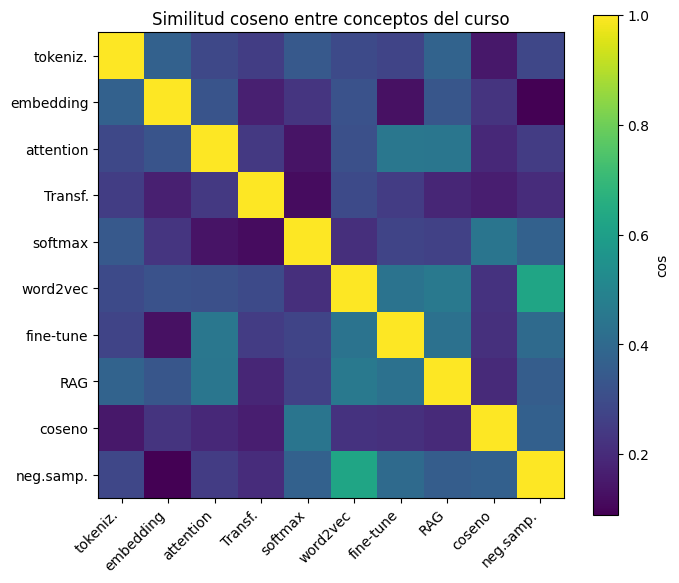


Par más parecido: 'word2vec' y 'neg.samp.' -> cos = 0.624


In [ ]:
import matplotlib.pyplot as plt

etiquetas = ["tokeniz.", "embedding", "attention", "Transf.", "softmax",
             "word2vec", "fine-tune", "RAG", "coseno", "neg.samp."]

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(M, cmap="viridis")
ax.set_xticks(range(n)); ax.set_xticklabels(etiquetas, rotation=45, ha="right")
ax.set_yticks(range(n)); ax.set_yticklabels(etiquetas)
plt.colorbar(im, label="cos")
plt.title("Similitud coseno entre conceptos del curso")
plt.tight_layout(); plt.show()

# ¿Qué par de conceptos DISTINTOS quedó más cerca? (excluimos la diagonal)
Mx = M.copy(); np.fill_diagonal(Mx, -1)
i, j = np.unravel_index(np.argmax(Mx), Mx.shape)
print(f"\nPar más parecido: '{etiquetas[i]}' y '{etiquetas[j]}' -> cos = {M[i, j]:.3f}")

> **Leé el mapa.** Los conceptos que hablan de lo mismo se iluminan juntos: *word2vec* y *negative sampling*, o *embedding* y *coseno*, quedan cerca; *softmax* y *fine-tuning* quedan lejos. Nadie le dijo al modelo qué conceptos se relacionan: lo dedujo del significado de las definiciones. Esa geometría es lo que hace posible el paso siguiente.

## 5 · Búsqueda semántica = la «R» de RAG

**El payoff.** Búsqueda semántica es esto: llega una **query**, la embebemos con el **mismo** modelo que usamos para el corpus, y devolvemos los documentos con mayor coseno. Nada más. Eso —query + documentos → coseno → top-k— es, tal cual, la **recuperación** de un sistema de RAG (la "R"). Es lo que la Semana 8 construye en serio.

**Lo construimos a mano primero** (coseno + ordenar), y después miramos el helper de la librería.

In [ ]:
def buscar(query, k=3):
    # 1. Embebemos la query con EL MISMO modelo que el corpus (clave: mismo espacio vectorial).
    q_emb = sbert_ml.encode(query)
    # 2. Coseno de la query contra cada documento.
    scores = [coseno(q_emb, d) for d in doc_emb]
    # 3. Ordenamos de mayor a menor y devolvemos los top-k.
    orden = np.argsort(scores)[::-1][:k]
    return [(int(i), scores[int(i)]) for i in orden]

# Una pregunta de alumno, escrita con OTRAS palabras que las definiciones (a propósito).
query = "cómo le doy a un modelo información que no está en su entrenamiento"
print(f"Query: {query!r}\n")
for i, s in buscar(query):
    print(f"  cos={s:.3f}  [{i}] {documentos[i][:75]}...")

Query: 'cómo le doy a un modelo información que no está en su entrenamiento'

  cos=0.616  [6] El fine-tuning ajusta un modelo ya pre-entrenado sobre datos de una tarea e...
  cos=0.423  [5] word2vec aprende embeddings de palabra prediciendo el contexto de cada una;...
  cos=0.411  [7] RAG (retrieval-augmented generation) recupera documentos relevantes por sim...


**Fijate lo que pasó.** La query no comparte casi ninguna palabra con la definición de RAG ("información que no está en su entrenamiento" vs "recupera documentos... contexto... información que no tenía"), y sin embargo el doc de RAG salió primero. Eso es **búsqueda semántica**: matchea *significado*, no palabras. Un buscador por palabras clave —como el retriever naive de la Clase 1 (`que_es_realmente_la_ia`, §3)— acá fallaría.

> **La invariante que importa (y que te mordió con `OpenAIEmbeddings`).** La query y los documentos tienen que embeberse con el **mismo** modelo. El coseno sólo tiene sentido dentro de un mismo espacio vectorial: si embebés el corpus con un modelo y la query con otro, los vectores viven en espacios distintos y el ranking no es confiable. Por eso, si cambiás de embedder, tenés que **re-indexar todo el corpus**.

In [ ]:
# ¿Por qué "el mismo modelo"? Porque cada modelo arma su PROPIO espacio.
qA = sbert.encode(query)      # modelo A: all-MiniLM (inglés)
qB = sbert_ml.encode(query)   # modelo B: multilingüe

print("Misma query, dos modelos distintos:")
print(f"  dim modelo A: {qA.shape[0]}   dim modelo B: {qB.shape[0]}")
print(f"  cos(qA, qB) = {coseno(qA, qB):.3f}   <- casi no se parecen: son espacios DISTINTOS\n")
print("Moraleja: NO podés embeber el corpus con A y la query con B. Elegís UN modelo y lo usás para todo.")
print("(Muchos modelos ni comparten dimensión: nomic-embed-text da 768-dim, no 384 — el coseno ni se calcularía.)")

Misma query, dos modelos distintos:
  dim modelo A: 384   dim modelo B: 384
  cos(qA, qB) = 0.236   <- casi no se parecen: son espacios DISTINTOS

Moraleja: NO podés embeber el corpus con A y la query con B. Elegís UN modelo y lo usás para todo.
(Muchos modelos ni comparten dimensión: nomic-embed-text da 768-dim, no 384 — el coseno ni se calcularía.)


In [ ]:
from sentence_transformers import util

# El helper de la librería hace lo mismo que 'buscar', optimizado. Necesita tensores.
corpus_t = sbert_ml.encode(documentos, convert_to_tensor=True)
query_t = sbert_ml.encode(query, convert_to_tensor=True)

hits = util.semantic_search(query_t, corpus_t, top_k=3)[0]   # [0] = resultados de la 1ra query
print(f"Query: {query!r}\n")
for h in hits:
    print(f"  score={h['score']:.3f}  [{h['corpus_id']}] {documentos[h['corpus_id']][:70]}...")

Query: 'cómo le doy a un modelo información que no está en su entrenamiento'

  score=0.616  [6] El fine-tuning ajusta un modelo ya pre-entrenado sobre datos de una ta...
  score=0.423  [5] word2vec aprende embeddings de palabra prediciendo el contexto de cada...
  score=0.411  [7] RAG (retrieval-augmented generation) recupera documentos relevantes po...


In [ ]:
# Probemos varias preguntas más, todas con palabras distintas a las definiciones.
for q in [
    "qué hace que cada palabra preste atención a las otras",
    "cómo se convierte una palabra en un número",
    "por qué las salidas del modelo suman uno",
]:
    i, s = buscar(q, k=1)[0]
    print(f"Q: {q}")
    print(f"   -> cos={s:.3f}  [{i}] {documentos[i][:60]}...\n")

Q: qué hace que cada palabra preste atención a las otras
   -> cos=0.507  [2] La self-attention deja que cada token mire a los demás y arm...

Q: cómo se convierte una palabra en un número
   -> cos=0.257  [5] word2vec aprende embeddings de palabra prediciendo el contex...

Q: por qué las salidas del modelo suman uno
   -> cos=0.483  [6] El fine-tuning ajusta un modelo ya pre-entrenado sobre datos...



> **Checkpoint.** Las tres preguntas caen en el concepto correcto (*self-attention*, *tokenización/embedding*, *softmax*) aunque no compartan las palabras. Ya tenés un **retriever semántico** funcionando: es la "R" de RAG.

**Lo que falta para RAG completo.** Retrieval devuelve *documentos*; RAG los usa para **generar** una respuesta. En la §6 cerramos el círculo con el stack que se usa de verdad —y libre— haciéndolo **Ollama-nativo**, el mismo motor del curso.

## 6 · Del retrieval a RAG: el stack Ollama-nativo

Hasta acá embebimos con `sentence-transformers`, ideal para *ver el mecanismo*. Para armar RAG de verdad —y **sin APIs pagas ni lock-in de proveedor** (el problema de `OpenAIEmbeddings`)— usamos el mismo **Ollama** que ya corre el LLM del curso: Ollama también sirve **modelos de embeddings**, local, sin API key y a costo cero.

**La clave para *ver* qué aporta RAG.** Si le preguntamos al modelo algo que ya sabe (qué es un token, qué es softmax), no vamos a notar la diferencia: contesta parecido con o sin RAG. RAG se luce cuando el dato **no está en sus pesos**. Por eso armamos una base con hechos de **esta materia** —fechas, evaluación— que el modelo no tiene forma de conocer, embebemos con `nomic-embed-text`, recuperamos por coseno (como en la §5) y comparamos la respuesta **sin RAG vs con RAG**.

*El tratamiento completo (chunking, vector store, reranking) es la Unidad 4, Semana 8. Acá armamos el esqueleto mínimo para ver la pieza entera funcionando.*

In [ ]:
# --- Bootstrap de Ollama (el mismo de la Clase 1) ---
!apt-get -qq update && apt-get -qq install -y zstd
!curl -fsSL https://ollama.com/install.sh | sh

import subprocess, time, requests
subprocess.Popen(["ollama", "serve"])   # servidor en segundo plano
for _ in range(30):
    try:
        requests.get("http://localhost:11434/api/tags", timeout=2)
        print("Ollama está listo."); break
    except requests.exceptions.RequestException:
        time.sleep(1)
else:
    print("El servidor tardó; volvé a correr esta celda.")

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Selecting previously unselected package zstd.
(Reading database ... 118422 files and directories currently installed.)
Preparing to unpack .../zstd_1.4.8+dfsg-3build1_amd64.deb ...
Unpacking zstd (1.4.8+dfsg-3build1) ...
Setting up zstd (1.4.8+dfsg-3build1) ...
Processing triggers for man-db (2.10.2-1) ...
>>> Installing ollama to /usr/local
>>> Downloading ollama-linux-amd64.tar.zst
######################################################################## 100.0%
>>> Creating ollama user...
>>> Adding ollama user to video group...
>>> Adding current user to ollama group...
>>> Creating ollama systemd service...
>>> The Ollama API is now available at 127.0.0.1:11434.
>>> Install complete. Run "ollama" from the command line.
Ollama está listo.


In [ ]:
!pip -q install ollama

# Dos modelos locales (una vez por sesión):
# - nomic-embed-text: embedder chico (~274 MB), corre hasta en CPU. Es el más usado en Ollama.
# - qwen3:8b: el LLM generador del curso (~5 GB).
!ollama pull nomic-embed-text
!ollama pull qwen3:8b

**El embedder de Ollama, en una línea.** Con el servidor corriendo, embeber es una sola llamada: `ollama.embed(model="nomic-embed-text", input=...)`. Sin API key, local, a costo cero. **Este es el reemplazo directo de `OpenAIEmbeddings`** —mismo rol (texto → vector para recuperar), pero libre y sin proveedor atado. Lo usamos para embeber el corpus y, enseguida, para armar el RAG.

In [ ]:
import ollama

def embeber_ollama(textos):
    # ollama.embed acepta una lista y devuelve un embedding por texto (sin API key, local).
    resp = ollama.embed(model="nomic-embed-text", input=textos)
    return np.array(resp.embeddings, dtype=np.float32)

# RAG se luce cuando la respuesta NO está en los pesos del modelo. Por eso la base son
# hechos de ESTA materia: cosas que qwen3 no tiene forma de conocer.
base = [
    "El primer trabajo práctico (TP1) de la materia se entrega el 27 de septiembre.",
    "La evaluación es 100% por trabajos prácticos grupales, en grupos de hasta 4 integrantes.",
    "El examen final es único y de tipo aprobado/desaprobado, sin nota numérica.",
    "La infraestructura del curso es libre: Ollama y HuggingFace, sin APIs pagas.",
    "El proyecto final se entrega el 29 de noviembre.",
]

# Embebemos la base con Ollama (nomic da 768-dim: su propio espacio, distinto al de SBERT).
base_emb = embeber_ollama(base)
print("Base embebida con nomic-embed-text:", base_emb.shape, "(768-dim → otro espacio que SBERT)")

Base embebida con nomic-embed-text: (5, 768) (768-dim → otro espacio que SBERT)


In [ ]:
def responder(pregunta, usar_rag, k=2):
    if usar_rag:
        # RECUPERAR: top-k de la base por coseno (mismo embedder para la query y la base).
        q = embeber_ollama([pregunta])[0]
        scores = [coseno(q, d) for d in base_emb]
        top = [int(i) for i in np.argsort(scores)[::-1][:k]]
        print("  [retrieval] recuperado de la base:")
        for i in top:
            print(f"      cos={scores[i]:.3f}  {base[i]}")
        contexto = "\n".join(f"- {base[i]}" for i in top)
        prompt = (f"Usá SÓLO este contexto para responder.\n\n"
                  f"Contexto:\n{contexto}\n\n"
                  f"Pregunta: {pregunta}\nRespondé en una sola oración.")
    else:
        # SIN RAG: el modelo responde solo, con lo que tenga en los pesos.
        prompt = f"{pregunta}\nRespondé en una sola oración."
    r = ollama.chat(model="qwen3:8b", messages=[{"role": "user", "content": prompt}], think=False)
    return r.message.content.strip()

# La MISMA pregunta sin y con RAG. El dato no está en el modelo: ahí se ve qué aporta recuperar.
pregunta = "¿Cuándo se entrega el primer trabajo práctico de la materia?"

print("SIN RAG (no puede saberlo → inventa una fecha o esquiva):")
print("  ", responder(pregunta, usar_rag=False), "\n")

print("CON RAG (recupera el dato de la base y responde con él):")
print("  ", responder(pregunta, usar_rag=True))

SIN RAG (no puede saberlo → inventa una fecha o esquiva):
   El primer trabajo práctico de la materia se entrega al final de la primera semana de clases. 

CON RAG (recupera el dato de la base y responde con él):
  [retrieval] recuperado de la base:
      cos=0.848  El primer trabajo práctico (TP1) de la materia se entrega el 27 de septiembre.
      cos=0.611  La evaluación es 100% por trabajos prácticos grupales, en grupos de hasta 4 integrantes.
   El primer trabajo práctico de la materia se entrega el 27 de septiembre.


In [ ]:
# Otra pregunta, con palabras distintas a las de la base (retrieval semántico, no por keywords).
pregunta = "¿cómo se aprueba la materia?"

print("SIN RAG:")
print("  ", responder(pregunta, usar_rag=False), "\n")
print("CON RAG:")
print("  ", responder(pregunta, usar_rag=True))

SIN RAG:
   La materia se aprueba cuando el estudiante obtiene una calificación igual o superior al mínimo requerido por el sistema educativo. 

CON RAG:
  [retrieval] recuperado de la base:
      cos=0.676  El primer trabajo práctico (TP1) de la materia se entrega el 27 de septiembre.
      cos=0.618  La infraestructura del curso es libre: Ollama y HuggingFace, sin APIs pagas.
   Para aprobar la materia, se debe entregar correctamente el primer trabajo práctico (TP1) el 27 de septiembre y cumplir con la infraestructura del curso utilizando Ollama y HuggingFace sin APIs pagas.


**Lo que acabás de armar.** En unas pocas líneas: un embedder local (nomic vía Ollama) + recuperación por coseno + un LLM local (qwen3) generando sobre lo recuperado. Eso es un **RAG mínimo, completo y 100% libre** —el reemplazo directo del stack con `OpenAIEmbeddings`, sin API key ni proveedor atado.

Y cerramos el cabo suelto de la Clase 1: aquel retriever *naive* por palabras clave (que fallaba con sinónimos) ahora es un retriever **semántico** que matchea significado.

## Cierre: el mapa de la Parte 2

| paso | qué hicimos | herramienta |
|---|---|---|
| palabra → oración | el problema: necesitamos un vector por oración | — |
| baseline | promediar word vectors (y sus agujeros: orden, dilución, OOV) | GloVe (N1) |
| sentence embedding | un modelo que lee la oración entera | SBERT (`sentence-transformers`) |
| coseno entre oraciones | los significados parecidos caen cerca | la función de N1 |
| búsqueda semántica | query + docs → coseno → top-k = **la "R" de RAG** | `util.semantic_search` |
| RAG mínimo | recuperar + generar, todo local y libre | Ollama (`nomic-embed-text` + `qwen3`) |

**Lo que sigue — Unidad 4, Semana 8 (RAG desde cero):** lo de hoy es el esqueleto. Falta lo que lo hace escalar: **chunking** (partir documentos largos), un **vector store** de verdad (Chroma / pgvector / Qdrant) en vez de una lista de numpy, y **reranking** para afinar el top-k. La pieza central —embeber y recuperar por coseno— ya la tenés.

> **La bisagra, cerrada.** La Parte 1 preguntaba de dónde salen los vectores de palabra. La Parte 2 los llevó a la oración y montó recuperación semántica. De acá a RAG completo, sólo falta escala.